In [22]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1" # for debugging

import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
class SimpleGPT(nn.Module):
    def __init__(self, d_model, max_seq_len):
        super().__init__()
        self.d_model = d_model

        # Attention head
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.attn_out = nn.Linear(d_model, d_model)

        # Feed-forward
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

        # Layer norms
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        # Output
        self.output_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        _, seq_len, _ = x.shape

        # Self-attention with causal mask
        residual = x
        x = self.ln1(x)

        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_model)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(causal_mask, float('-inf'))
        attn = torch.softmax(attn, dim=-1)

        x = attn @ v
        x = self.attn_out(x)
        x = residual + x

        # Feed-forward
        x = x + self.ffn(self.ln2(x))

        # Output projection
        return self.output_proj(x)


class SimpleDequant(nn.Module):
    def __init__(self, max_seq_len: int, num_instruments: int):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.num_instruments = num_instruments

        self.gpt = SimpleGPT(
            d_model=num_instruments * 3,
            max_seq_len=max_seq_len,
        )
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, num_instruments, hov_size = x.shape

        assert seq_len <= self.max_seq_len, "max_seq_len exceeded."
        assert num_instruments == self.num_instruments
        assert hov_size == 3

        # Flatten each timestep to a single dimension
        x = x.flatten(start_dim=2)

        # Run the GPT
        y: torch.Tensor = self.gpt(x)

        # Reshape the output tensor
        y = y.reshape(batch_size, seq_len, num_instruments, hov_size)

        # Apply different activations to hits, offsets, and velocities
        hits = self.sigmoid(y[..., 0:1])
        offsets = 0.5 * self.tanh(y[..., 1:2])
        velocities = self.sigmoid(y[..., 2:3])

        # Concatenate along last dimension
        return torch.cat([hits, offsets, velocities], dim=-1)

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            x = x.unsqueeze(0) # add batch dimension
            y = self.forward(x)

            # remove batch dimension and return the last (predicted) timestep only
            return y[0, -1]

In [141]:
def plot_pattern(pattern, *, ax=None, instruments=["Kick", "Snare"]):
    seq_len, num_instruments, _hov = pattern.shape
    assert len(instruments) == num_instruments, "Number of instruments in the pattern does not match the number of instrument labels"

    # create a meshgrid that is displayed in the background
    xs = np.arange(seq_len)
    ys = np.arange(num_instruments)
    mx, my = np.meshgrid(xs, ys)

    if ax is None:
        ax = plt.subplot(1, 1, 1)

    # plot the background grid
    ax.scatter(mx, my, s=1000, facecolors="none", edgecolors="black", linestyle="--", alpha=0.3)

    # plot the actual pattern dots
    ax.scatter(
        mx + pattern[mx, my, 1], # apply the offset
        my,
        s=1000,
        edgecolors="none",
        c=pattern[mx, my, 2], # use velocity as color
        cmap="binary", # 0 = white, 1 = black
        alpha=pattern[mx, my, 0] > 0.5, # use hits as alpha mask
    )

    ax.set_xbound(xs[0] - 0.5, xs[-1] + 0.5)
    ax.set_xticks(xs)

    ax.set_ybound(ys[0] - 0.5, ys[-1] + 0.5)
    ax.set_yticks(ys)
    ax.set_yticklabels(instruments)

Training...
Epoch 0, Loss: 0.186819
Epoch 100, Loss: 0.086024
Epoch 200, Loss: 0.040737
Epoch 300, Loss: 0.038520
Epoch 400, Loss: 0.030794
Epoch 500, Loss: 0.022129
Epoch 600, Loss: 0.020934
Epoch 700, Loss: 0.020508
Epoch 800, Loss: 0.020055
Epoch 900, Loss: 0.019682
torch.Size([3, 2, 3])
torch.Size([3, 2, 3])
torch.Size([3, 2, 3])
torch.Size([3, 2, 3])


/tmp/ipykernel_2735/1986815781.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_2735/1986815781.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


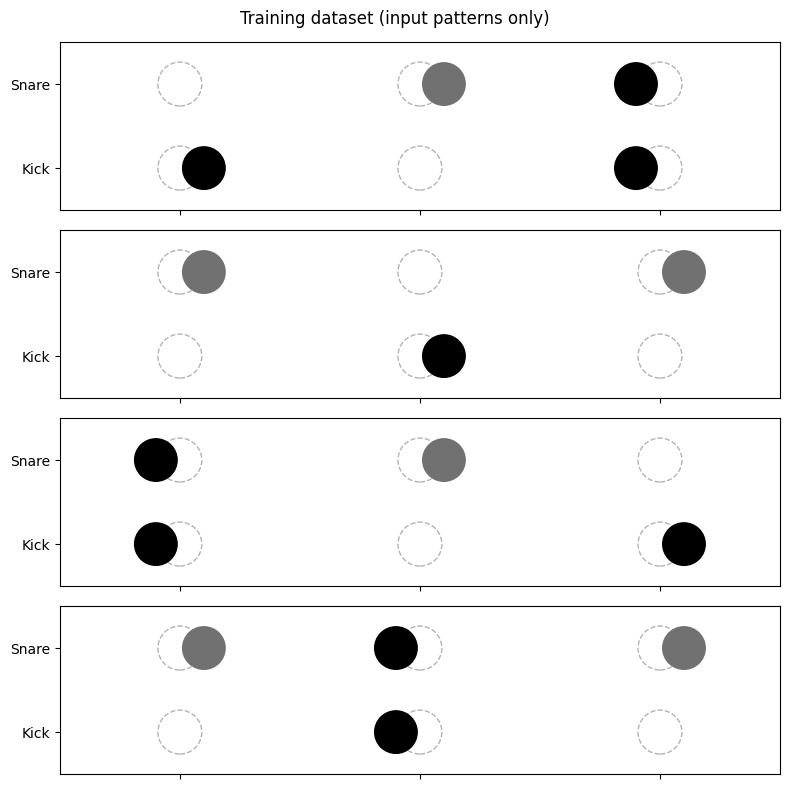

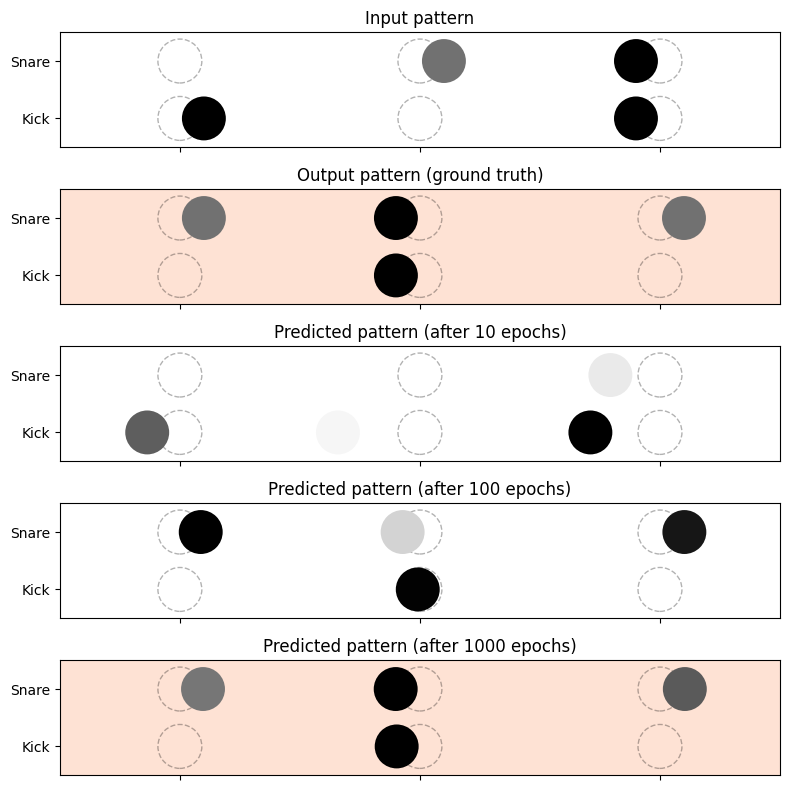

In [194]:
# Basic test pattern
pattern = torch.tensor([
    [[1.0, 0.1, 0.9], [0.0, 0.0, 0.0]],
    [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
    [[1.0, -0.1, 0.9], [1.0, -0.1, 0.9]],
    [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
])

# Create different samples by shifting the test pattern
xs = torch.zeros((4, 3, 2, 3))
ys = torch.zeros((4, 3, 2, 3))
for i in range(4):
    shifted_pattern = torch.roll(pattern, i, dims=0)
    xs[i] = shifted_pattern[:-1]
    ys[i] = shifted_pattern[1:]

# Create a basic optimizer
model = SimpleDequant(4, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

eval_epochs = [10, 100, 1000]
# eval_input = torch.tensor([
#     [[1.0, 0.0, 0.9], [0.0, 0.0, 0.0]],
#     [[0.0, 0.0, 0.0], [0.0, 0.6, 0.9]],
#     [[0.0, -0.5, 0.3], [1.0, -0.1, 0.9]],
# ])
eval_input = xs[0]
eval_output = ys[0]
eval_predictions = []

print("Training...")
for epoch in range(1000):
    # use the whole dataset as a single batch
    output = model(xs)
    loss = criterion(output, ys)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    # Run evaluation on certain epochs
    for eval_epoch in eval_epochs:
        if epoch == eval_epoch - 1:
            eval_predictions.append(model.forward(eval_input.unsqueeze(0))[0].detach())



# Plot the dataset
fig, axes = plt.subplots(len(xs), 1)
fig.set_size_inches(8, 8)

for i, (pattern, ax) in enumerate(zip(xs, axes)):
    print(pattern.shape)
    plot_pattern(pattern.numpy(), ax=ax)
    ax.set_xticklabels([])

fig.suptitle("Training dataset (input patterns only)")
fig.tight_layout()
fig.show()
fig.savefig("output/modelv1_dataset.svg")


# Plot the resulting patterns
fig, (axi, axo, *axps) = plt.subplots(2 + len(eval_predictions), 1)
fig.set_size_inches(8, 8)

plot_pattern(eval_input.numpy(), ax=axi)
axi.set_title("Input pattern")
axi.set_xticklabels([])

plot_pattern(eval_output.numpy(), ax=axo)
axo.set_title("Output pattern (ground truth)")
axo.set_xticklabels([])
axo.set_facecolor("#FC7229")
axo.patch.set_alpha(0.2)

for eval_epoch, eval_prediction, axp in zip(eval_epochs, eval_predictions, axps):
    plot_pattern(eval_prediction.numpy(), ax=axp)
    axp.set_title(f"Predicted pattern (after {eval_epoch} epochs)")
    axp.set_xticklabels([])

    if eval_epoch == 1000:
        axp.set_facecolor("#FC7229")
        axp.patch.set_alpha(0.2)

fig.tight_layout()
fig.show()
fig.savefig("output/modelv1_evaluation.svg")